# Specific Test V — Gravitational Lens Finding & Data Pipelines

## The Task

To Build a binary classifier to identify strong gravitational lenses from non-lensed galaxies using PyTorch. The dataset contains observational images in three filter channels, already splitted into pre-defined train and test folders.

**The Problem:** The dataset is heavily class-imbalanced. Non-lenses vastly outnumber lensed galaxies. We must build a model that account for this and avoids a trivially high accuracy by simply predicting the majority class.

## What I Chose to Do?

- **Model Architecture:** Transfer learning with **ResNet-18** CNN model was used which I think can serve as a powerful CNN backbone. Since lensing features are spatially structured, CNN is the ideal choice. I tested out different CNN models like EfficientNet, MobileNet, etc. as well, before coming to the conclusion of using ResNet as it gave the best performance.

- **Class Imbalance:** I used `WeightedRandomSampler` here, read that in a research paper sometime ago. This oversamples the minority (lens) class during training batches, ensuring the model sees a balanced distribution of the train set.

- **Loss Function:** Used the standard Binary Cross-Entropy (`BCELoss`) Loss Function. Used sigmoid in the end to convert the logits into probabilities.

- **Regularization:** I used Dropout (p=0.3) before the final linear layer to reduce overfitting along with early stopping. ResNet-18 is big model compared to this small dataset, so regularizing plays a big role in preventing overfitting. Used lower learning rate intentionally so loss goes down smoothly instead of mountain-like peaks. All these are done on the dev set following the standard procedure.

- **Evaluation Metrics:** ROC curve and AUC score on the test set is reported in the end.

> A note on AI tools - all the ideas and decisions are my own based on my experience and whatever I read from articles, research papers and the internet.However, I used AI assistent to make broiler code, syntax and debugging

## Imports & Dataset Loading

In [ ]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import copy as _copy
from sklearn.model_selection import train_test_split

DATASET_ROOT = "/kaggle/input/datasets/salilmandal/deeplense-lensefinding-dataset"

paths = {
    "train_lens": os.path.join(DATASET_ROOT, "train_lenses"),
    "train_nonlens": os.path.join(DATASET_ROOT, "train_nonlenses"),
    "test_lens": os.path.join(DATASET_ROOT, "test_lenses"),
    "test_nonlens": os.path.join(DATASET_ROOT, "test_nonlenses"),
}

for name, p in paths.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory for '{name}': {p}")

class GravitationalLensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir):
        self.lens_files    = sorted(glob.glob(os.path.join(lens_dir,    "*.npy")))
        self.nonlens_files = sorted(glob.glob(os.path.join(nonlens_dir, "*.npy")))
        self.all_files = self.lens_files + self.nonlens_files
        self.labels    = [1] * len(self.lens_files) + [0] * len(self.nonlens_files)

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        image = np.load(self.all_files[idx], mmap_mode="r").astype(np.float32)
        return torch.from_numpy(image), torch.tensor(self.labels[idx], dtype=torch.float32)

train_dataset = GravitationalLensDataset(paths["train_lens"], paths["train_nonlens"])
test_dataset = GravitationalLensDataset(paths["test_lens"],  paths["test_nonlens"])

# Displaying Data
print(f"Train samples : {len(train_dataset):,}  "
      f"(lenses={len(train_dataset.lens_files):,}  "
      f"non-lenses={len(train_dataset.nonlens_files):,})")
print(f"Test  samples : {len(test_dataset):,}  "
      f"(lenses={len(test_dataset.lens_files):,}  "
      f"non-lenses={len(test_dataset.nonlens_files):,})")


Train samples : 30,405  (lenses=1,730  non-lenses=28,675)
Test  samples : 19,650  (lenses=195  non-lenses=19,455)


## Device Configuration

This detects and assign the available compute device (GPU if available, else CPU). I Used Kaggle resources (GPU T4x2) to train the model in this notebook. 

I have made sure that this notebook runs without GPU as well which makes it more reproducible, perfect for open-source I think.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## A Little Note

Before committing to full training, I chose to verify that the data loading and forward/backward pass works correctly on a tiny subset (10 lenses + 10 non-lenses). I have kept the code below for reference.

This prevents wasting GPU time on training a model which is broken or badly designed. As I experimented a lot, retraining multiple models, this was something that I felt very necessary after some point finally saving me lots of time.

In [ ]:
def run_fixed_diagnostic(dataset, device):
    print("--- Checking the Pipeline on Finite Samples ---")
    lens_indices = [i for i, label in enumerate(dataset.labels) if label == 1][:10]
    nonlens_indices = [i for i, label in enumerate(dataset.labels) if label == 0][:10]
    diag_indices = lens_indices + nonlens_indices
    
    diag_subset = Subset(dataset, diag_indices)
    diag_loader = DataLoader(diag_subset, batch_size=20, shuffle=True)
    
    # Making a Simple model, Smaller Model for testing 
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(nn.Linear(model.fc.in_features, 1), nn.Sigmoid())
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    
    # Test learning
    model.train()
    images, labels = next(iter(diag_loader))
    images, labels = images.to(device), labels.to(device).view(-1, 1)
    
    with torch.no_grad():
        initial_auc = roc_auc_score(labels.cpu().numpy(), model(images).cpu().numpy())
    
    # Checking if my model can truly overfit the data.
    for _ in range(10):
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        
    final_auc = roc_auc_score(labels.cpu().numpy(), model(images).detach().cpu().numpy())
    print(f"Initial AUC: {initial_auc:.4f} --> Final AUC: {final_auc:.4f}")
    if final_auc > initial_auc: print("\nPipeline is working and model is learning.")

run_fixed_diagnostic(train_dataset, device)

--- Checking the Pipeline on Finite Samples ---
Initial AUC: 0.3900 --> Final AUC: 1.0000

Pipeline is working and model is learning.


## Training the Final Model

### Data Splitting
The training set is split **90:10** (stratified) into train and validation subsets, so that the dev set doesn't gives biased results and prevents incorrect hyperparameter tuning.

### Model Architecture
- **Backbone:** ResNet-18 (pretrained weights not used; trained from scratch on lensing data)

- **Head:** `Dropout(0.3)` → `Linear(512, 1)` → `Sigmoid()`

I was using pretrained weights trained on ImageNet before, but the model was breaking everytime, most likely due to data imbalance and the difference between normal pictures and lensing data. Hence tranined it from scratch on lensing data which gave satisfying results. Additional dropout regularization helps prevent overfitting the large model on small training set.

### Optimizer & Scheduler
- **Optimizer:** Used Adam with `lr=1e-5`

- **LR Scheduler:** This is another method I read online, and this proved to be quite beneficial. `ReduceLROnPlateau` monitors val AUC, reduces LR by 0.5× after 3 stagnant epochs

- **Early Stopping:** Training stops if validation AUC does not improve by `1e-4` for 5 consecutive epochs. Best weights are restored at the end.

`A small note` - I should have removed the stride = 2 used in the ResNet's architecture, but I didn't fell like training the whole thing again as I had little time left. If I had more time, I would have fixed that.

In [ ]:
# Splitting the training data into train and dev set.
all_indices = list(range(len(train_dataset)))
train_idx, val_idx = train_test_split(
    all_indices, test_size=0.1, random_state=42,
    stratify=train_dataset.labels
)
train_sub = torch.utils.data.Subset(train_dataset, train_idx)
val_sub   = torch.utils.data.Subset(train_dataset, val_idx)

# This weight sampler minimizes the drastic effect due to heavy class imbalance present in the given lensing data
train_labels   = [train_dataset.labels[i] for i in train_sub.indices]
class_counts   = np.bincount(train_labels)
weights        = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_sub,    batch_size=64, sampler=sampler, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_sub,      batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Defining the Model
model  = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 1),
    nn.Sigmoid()
)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model) #using parallel computation in case multiple GPUs are present.
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.BCELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

# Early Stopping Config
ES_PATIENCE       = 5
ES_MIN_DELTA      = 1e-4

best_val_auc      = 0.0
best_weights      = None
epochs_no_improve = 0

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_auc":  [], "val_auc":  [],
}

print(f"Training on {device} | max {NUM_EPOCHS} epochs | early-stopping patience={ES_PATIENCE}\n")

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # Training
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    t_preds, t_targets = [], []

    for imgs, lbls in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True).view(-1, 1)

        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        t_loss    += loss.item() * imgs.size(0)
        t_correct += ((out > 0.5).float() == lbls).sum().item()
        t_total   += imgs.size(0)
        t_preds.extend(out.detach().cpu().numpy())
        t_targets.extend(lbls.cpu().numpy())

    # Validation
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    v_preds, v_targets = [], []

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True).view(-1, 1)
            out  = model(imgs)
            v_loss    += criterion(out, lbls).item() * imgs.size(0)
            v_correct += ((out > 0.5).float() == lbls).sum().item()
            v_total   += imgs.size(0)
            v_preds.extend(out.cpu().numpy())
            v_targets.extend(lbls.cpu().numpy())

    # Keeping Track of different metrics
    train_auc = roc_auc_score(t_targets, t_preds)
    val_auc   = roc_auc_score(v_targets, v_preds)

    history["train_loss"].append(t_loss / t_total)
    history["val_loss"].append(v_loss / v_total)
    history["train_acc"].append(t_correct / t_total)
    history["val_acc"].append(v_correct / v_total)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Loss: {history['train_loss'][-1]:.3f}/{history['val_loss'][-1]:.3f} | "
          f"AUC: {train_auc:.4f}/{val_auc:.4f}", end="")

    # Early Stopping Mechanism
    if val_auc > best_val_auc + ES_MIN_DELTA:
        best_val_auc      = val_auc
        m = model.module if hasattr(model, 'module') else model
        best_weights = _copy.deepcopy(m.state_dict())
        epochs_no_improve = 0
        print("  best saved", end="")
    else:
        epochs_no_improve += 1
        print(f"  (no improve {epochs_no_improve}/{ES_PATIENCE})", end="")

    print()

    if epochs_no_improve >= ES_PATIENCE:
        print(f"\nEarly stopping triggered after epoch {epoch+1}.")
        break

# Restoring best checkpoint
m = model.module if hasattr(model, 'module') else model
m.load_state_dict(best_weights)
print(f"\nBest val AUC: {best_val_auc:.4f}  (weights restored)")

Using 2 GPUs
Training on cuda | max 30 epochs | early-stopping patience=5

Epoch 01/30 (62.1s) | Loss: 0.305/0.218 | AUC: 0.9450/0.9661  best saved
Epoch 02/30 (43.4s) | Loss: 0.143/0.125 | AUC: 0.9863/0.9650  (no improve 1/5)
Epoch 03/30 (37.9s) | Loss: 0.083/0.136 | AUC: 0.9944/0.9685  best saved
Epoch 04/30 (36.8s) | Loss: 0.060/0.121 | AUC: 0.9967/0.9681  (no improve 1/5)
Epoch 05/30 (39.5s) | Loss: 0.044/0.147 | AUC: 0.9980/0.9679  (no improve 2/5)
Epoch 06/30 (34.0s) | Loss: 0.037/0.141 | AUC: 0.9985/0.9622  (no improve 3/5)
Epoch 07/30 (34.6s) | Loss: 0.031/0.144 | AUC: 0.9989/0.9675  (no improve 4/5)
Epoch 08/30 (34.9s) | Loss: 0.025/0.126 | AUC: 0.9993/0.9627  (no improve 5/5)

Early stopping triggered after epoch 8.

Best val AUC: 0.9685  (weights restored)


## Training History — Loss, Accuracy & AUC Curves

Visualize how the model evolved over training epochs across three metrics:
- **Loss:** Binary cross-entropy on train vs. validation.
- **Accuracy:** Fraction of correct binary predictions at threshold 0.5.
- **AUC:** Area under the ROC curve — the primary evaluation metric, threshold-independent.

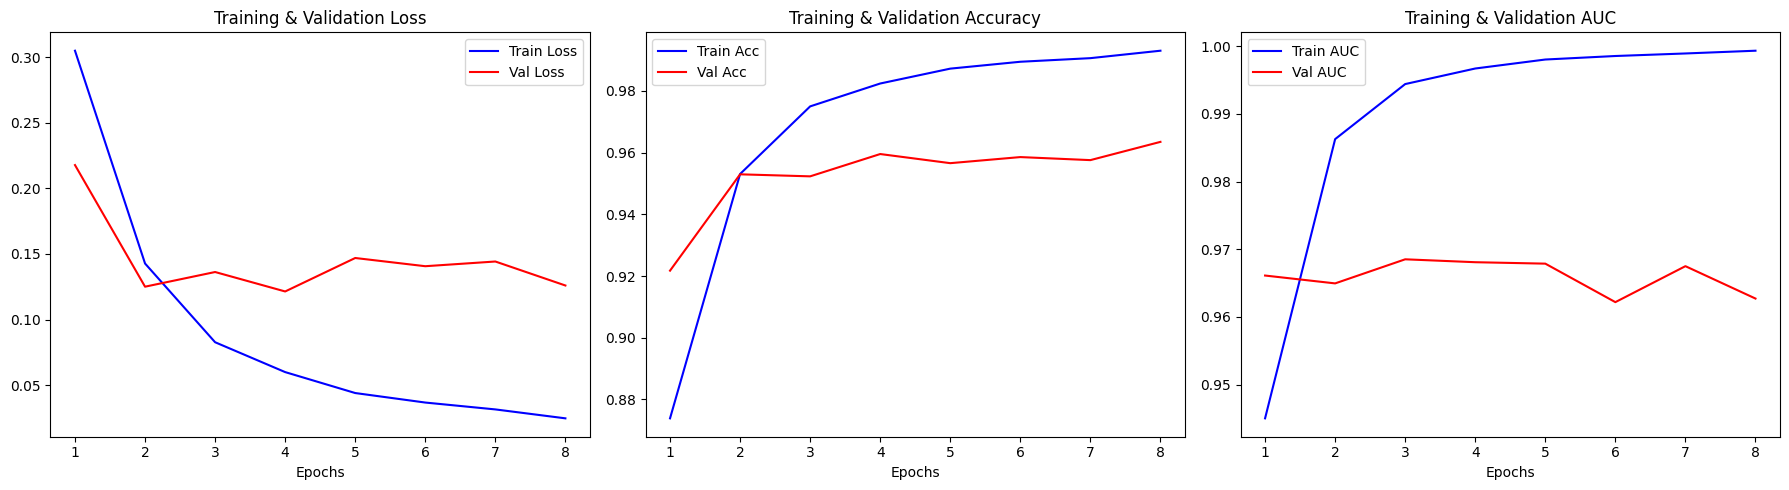

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Loss Curve
    axs[0].plot(epochs, history['train_loss'], 'b', label='Train Loss')
    axs[0].plot(epochs, history['val_loss'], 'r', label='Val Loss')
    axs[0].set_title('Training & Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].legend()

    # 2. Accuracy Curve
    axs[1].plot(epochs, history['train_acc'], 'b', label='Train Acc')
    axs[1].plot(epochs, history['val_acc'], 'r', label='Val Acc')
    axs[1].set_title('Training & Validation Accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].legend()

    # 3. AUC Curve 
    axs[2].plot(epochs, history['train_auc'], 'b', label='Train AUC')
    axs[2].plot(epochs, history['val_auc'], 'r', label='Val AUC')
    axs[2].set_title('Training & Validation AUC')
    axs[2].set_xlabel('Epochs')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluation on Test Set

Evaluating the model on the held-out test set using a threshold of 0.5.


The confusion matrix tells us:
- **True Positives:** Lenses correctly identified.
- **True Negatives:** Non-lenses correctly rejected.
- **False Positives:** Non-lenses incorrectly flagged as lenses.
- **False Negatives:** Lenses missed by the model.

Given the class imbalance, false negatives are the biggest concern here. Choosing a different threshold might have caused difference in the results following the AUC-ROC Curve, but I used the default threshold here without much overthinking, as it was used during Hyperparameter turning before.

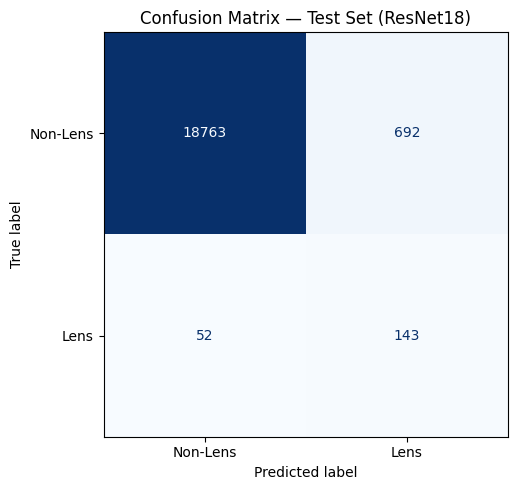

True Positives  (Lens correctly identified)    : 143
True Negatives  (Non-lens correctly identified): 18763
False Positives (Non-lens predicted as Lens)   : 692
False Negatives (Lens predicted as Non-lens)   : 52
Accuracy : 0.9621


In [ ]:
def plot_confusion_matrix(model, test_loader, device, threshold=0.5):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            out  = model(imgs).squeeze(1)
            preds = (out.cpu() > threshold).float()
            all_labels.extend(lbls.numpy())
            all_preds.extend(preds.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Lens", "Lens"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix — Test Set (ResNet18)")
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"True Positives  (Lens correctly identified)    : {tp}")
    print(f"True Negatives  (Non-lens correctly identified): {tn}")
    print(f"False Positives (Non-lens predicted as Lens)   : {fp}")
    print(f"False Negatives (Lens predicted as Non-lens)   : {fn}")
    print(f"Accuracy : {(tp + tn) / (tp + tn + fp + fn):.4f}")

plot_confusion_matrix(model, test_loader, device)

## Final ROC Curve & AUC Score

Plotting the Receiver Operating Characteristic (ROC) curves for the train, validation, and test sets as asked in the task. 

- An AUC of **1.0** is perfect classification.
- An AUC of **0.5** is equivalent to random guessing.

I am showing the curves across all three splits cus they helps evaluating how much the model can generalize also points out if it is overfitting.

**Note :** The curves are jagged somewhere, that is because the lens images were very very less compared to non-lens data. Due to this heavy class imbalance, as the decision threshold sweeps across all values, the True Positive Rate changes in large discrete jumps. This produces the staircase-like appearance in the ROC curve rather than a 
smooth arc.

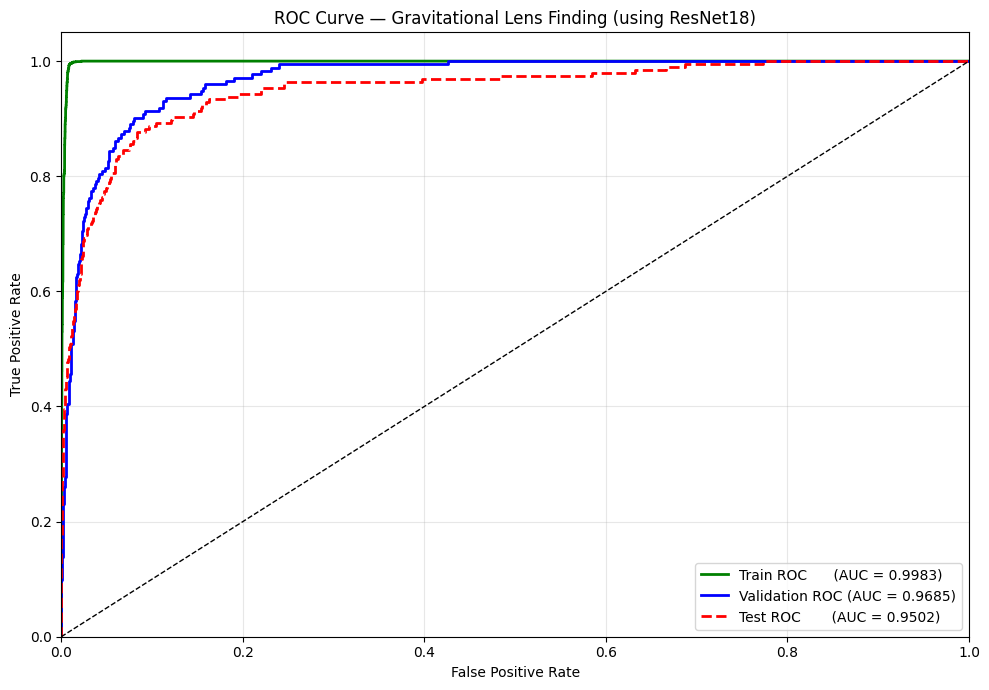

Train AUC      : 0.9983
Validation AUC : 0.9685
Test AUC       : 0.9502


In [ ]:
def plot_roc_curves(model, train_loader, val_loader, test_loader, device):
    model.eval()

    def get_probs(loader):
        all_labels, all_probs = [], []
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs = imgs.to(device)
                out  = model(imgs).squeeze(1)
                all_labels.extend(lbls.numpy())
                all_probs.extend(out.cpu().numpy())
        return np.array(all_labels), np.array(all_probs)

    train_labels, train_probs = get_probs(train_loader)
    val_labels,   val_probs   = get_probs(val_loader)
    test_labels,  test_probs  = get_probs(test_loader)

    fpr_tr, tpr_tr, _ = roc_curve(train_labels, train_probs)
    fpr_v,  tpr_v,  _ = roc_curve(val_labels,   val_probs)
    fpr_t,  tpr_t,  _ = roc_curve(test_labels,  test_probs)
    auc_tr = auc(fpr_tr, tpr_tr)
    auc_v  = auc(fpr_v,  tpr_v)
    auc_t  = auc(fpr_t,  tpr_t)

    plt.figure(figsize=(10, 7))
    plt.plot(fpr_tr, tpr_tr, color="green", lw=2,
             label=f"Train ROC      (AUC = {auc_tr:.4f})")
    plt.plot(fpr_v,  tpr_v,  color="blue",  lw=2,
             label=f"Validation ROC (AUC = {auc_v:.4f})")
    plt.plot(fpr_t,  tpr_t,  color="red",   lw=2, linestyle="--",
             label=f"Test ROC       (AUC = {auc_t:.4f})")
    plt.plot([0, 1], [0, 1], color="black", lw=1, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Gravitational Lens Finding (using ResNet18)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Train AUC      : {auc_tr:.4f}")
    print(f"Validation AUC : {auc_v:.4f}")
    print(f"Test AUC       : {auc_t:.4f}")

plot_roc_curves(model, train_loader, val_loader, test_loader, device)

## Save Model Weights

Savinh the best model's state dictionary to disk for reproducibility and future reference.

I will make sure to add these weights to the same github repo.

In [12]:
torch.save(m.state_dict(), "Task5_Model_wts.pth")